In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import awkward as ak
import sys
import pandas as pd
import matplotlib
# Add the absolute path to the directory containing your module
sys.path.insert(0, '../scripts')

from plotting import *
from common_defs import *

Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
Masking out zero values to fix different lengths:  (100000,) (100000,) (99996,)
[0.   0.   0.25 0.42 0.53 0.94]


In [2]:
#check number of cores and compile specter
num_cores = os.cpu_count()
print(f"Number of CPU cores: {num_cores}")

%load_ext autoreload
%autoreload 2

Number of CPU cores: 12


In [3]:
ttbar_xs = 678.6208346399999
zjet_xs = 14685.82119

zjet_hp_df
zjet_ps_df
zjet_had_df
zjet_jeppe_df
zjet_SEMD_hp_df
zjet_SEMD_ps_df
zjet_SEMD_had_df
zjet_b0_hp_df
zjet_b0_ps_df
zjet_b0_had_df
zjet_binf_hp_df
zjet_binf_ps_df
zjet_binf_had_df
zjet_b0p5_hp_df
zjet_b0p5_ps_df
zjet_b0p5_had_df
zjet_b2_hp_df
zjet_b2_ps_df
zjet_b2_had_df
ttbar_hp_df


KeyError: 'xmd'

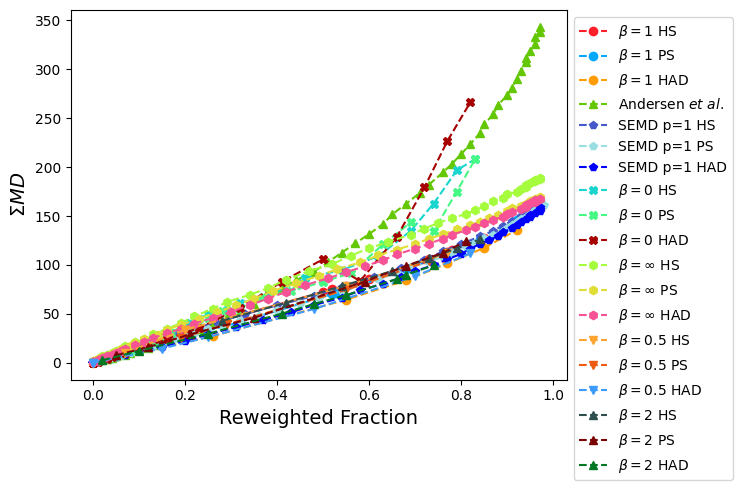

In [18]:
datasets = []
for key in dataFrames.keys():
    datasets.append(dataFrames[key])

processDict = {}
processDict["Zjets"] = {"name": "Z+jets"}
processDict["TTbar"] = {"name": r"$t\bar{t}$"}
    
# The legend looks bad for this, so I'm not using the script for now
#fractions = []
#for data in datasets:
#    fractions.append(data['df']["fraction"])
#
#plot_xmd(fractions, datasets, "HP")


for key in dataFrames.keys():
    print(key)
    df = dataFrames[key]['df']
    plt.plot(df["fraction"], dataFrames[key]["xmd"], color = dataFrames[key]['color'], marker = dataFrames[key]['marker'], label = dataFrames[key]['title'], linestyle = '--')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize = 10)
    plt.xlabel('Reweighted Fraction', fontsize = 14)
    plt.ylabel(r'$\Sigma MD$', fontsize = 14);



In [23]:
from plotting import *
comparisonDict = {}
comparisonDict["stages"] = {"weights": ["zjet_hp_df", "zjet_ps_df", "zjet_had_df"], "maxCellRadius": 30}
comparisonDict["betasHad"] = {"weights": ["zjet_b0_had_df", "zjet_b0p5_had_df", "zjet_had_df", "zjet_b2_had_df",  "zjet_binf_had_df"], "maxCellRadius": 250}
comparisonDict["betasHp"] = {"weights": ["zjet_b0_hp_df", "zjet_b0p5_hp_df", "zjet_hp_df", "zjet_b2_hp_df",  "zjet_binf_hp_df"], "maxCellRadius": 250}
comparisonDict["semdVemd_Had"] = {"weights": ["zjet_SEMD_had_df", "zjet_had_df", "zjet_jeppe_df"], "maxCellRadius": 50}
comparisonDict["stagesBeta0"] = {"weights": ["zjet_b0_hp_df", "zjet_b0_ps_df", "zjet_b0_had_df"], "maxCellRadius": 30}
comparisonDict["stagesBetap5"] = {"weights": ["zjet_b0p5_ps_df", "zjet_b0p5_hp_df", "zjet_b0p5_had_df"], "maxCellRadius": 100}
comparisonDict["stagesBeta2"] = {"weights": ["zjet_b2_hp_df", "zjet_b2_ps_df", "zjet_b2_had_df"], "maxCellRadius": 3}


for comparison in comparisonDict:
    fractions = []
    datasets = []
    for data in comparisonDict[comparison]["weights"]:
        datasets.append(dataFrames[data])
        fractions.append(dataFrames[data]['df']["fraction"])
        processTitle = processDict["Zjets"]["name"]
    plot_xmd(fractions, datasets, comparison, process_title = processTitle )


../plots/XMDs/xmd_stages
../plots/XMDs/xmd_betasHad
../plots/XMDs/xmd_betasHp
../plots/XMDs/xmd_semdVemd_Had
../plots/XMDs/xmd_stagesBeta0
../plots/XMDs/xmd_stagesBetap5
../plots/XMDs/xmd_stagesBeta2


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

NameError: name 'betainf_radii' is not defined

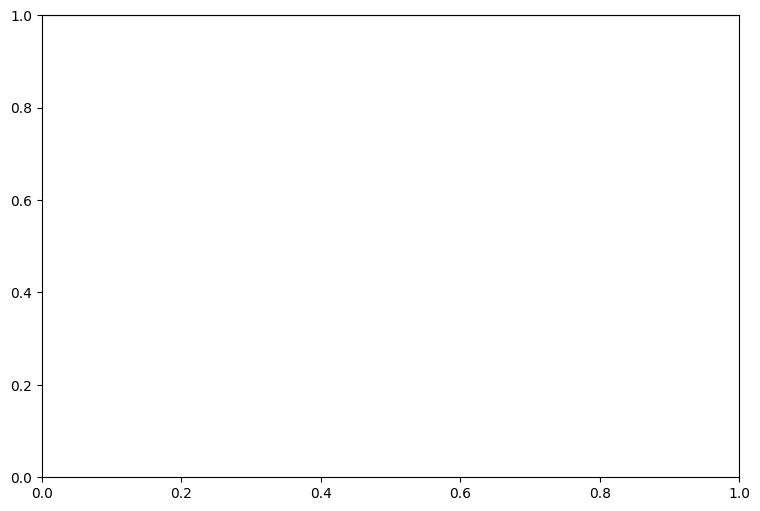

In [24]:
plt.figure(figsize=(9, 6))
plt.axhline(1, color = 'black', label = '100% Reweighted')
plt.plot(np.array(betainf_radii), hp_betainf_neg_percent, color = 'purple', marker = 'x', label = 'Hard Process β = ∞ EMD', linestyle = '--')
plt.plot(np.array(betainf_radii), sho_betainf_neg_percent, color = 'brown', marker = 'x', label = 'Showered β = ∞ EMD', linestyle = '--')
plt.plot(np.array(betainf_radii), had_betainf_neg_percent, color = 'pink', marker = 'x', label = 'Hadronization β = ∞ EMD', linestyle = '--')

plt.plot(np.array(hp_p1semd_radii), hp_p1semd_neg_percent, color = 'burlywood', marker = 'd', label = 'Hard Process p = 1 SEMD', linestyle = '--')
plt.plot(np.array(sho_p1semd_radii), sho_p1semd_neg_percent, color = 'olive', marker = 'd', label = 'Showered p = 1 SEMD', linestyle = '--')
plt.plot(np.array(had_p1semd_radii), had_p1semd_neg_percent, color = 'turquoise', marker = 'd', label = 'Hadronization p = 1 SEMD', linestyle = '--')

plt.plot(np.array(hp_radii), hp_neg_percent, color = 'red', marker = 'o', label = 'Hard Process β = 1 EMD', linestyle = '--')
plt.plot(np.array(sho_radii), sho_neg_percent, color = 'blue', marker = 'o', label = 'Showered β = 1 EMD', linestyle = '--')
plt.plot(np.array(had_radii), had_neg_percent, color = 'orange', marker = 'o', label = 'Hadronization β = 1 EMD', linestyle = '--')

plt.plot(np.array(hp_beta0p5_radii), hp_beta0p5_neg_percent, color = 'green', marker = 's', label = 'Hard Process β = 0.5 EMD', linestyle = '--')
plt.plot(np.array(sho_beta0p5_radii), sho_beta0p5_neg_percent, color = 'magenta', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')
plt.plot(np.array(had_beta0p5_radii), had_beta0p5_neg_percent, color = 'lightsalmon', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')
plt.plot(np.array(hp_beta2_radii), hp_beta2_neg_percent, color = 'mediumslateblue', marker = '+', label = 'Hard Process β = 2 EMD', linestyle = '--')
plt.plot(np.array(sho_beta2_radii), sho_beta2_neg_percent, color = 'plum', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')
plt.plot(np.array(had_beta2_radii), had_beta2_neg_percent, color = 'midnightblue', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')

plt.plot(np.array(beta0_radii), hp_beta0_neg_percent, color = 'lime', marker = '*', label = 'Hard Process β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii), sho_beta0_neg_percent, color = 'mediumturquoise', marker = '*', label = 'Showered β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii), had_beta0_neg_percent, color = 'mediumpurple', marker = '*', label = 'Hadronization β = 0 EMD', linestyle = '--')

plt.plot(np.array(hp_semd_radii), hp_semd_neg_percent, color = 'cyan', marker = 'v', label = 'Hard Process p = 2 SEMD', linestyle = '--')

plt.plot(np.array(zjet_jeppe_df["radius"].values), zjet_jeppe_df["fraction"].values, color = 'maroon', marker = 'v', label = 'Andersen et al', linestyle = '--')
plt.xscale('log')
plt.ylim([0,1.05])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize = 12)
plt.xlabel('Cell Radius [GeV]', fontsize = 14)
plt.ylabel('Reweighted Fraction', fontsize = 14)
plt.savefig('reweight_frac.png', bbox_inches='tight')

In [ ]:
plt.figure(figsize=(9, 6))
plt.axhline(1, color = 'black', label = '100% Reweighted')
plt.plot(np.array(betainf_radii), hp_betainf_neg_percent, color = 'purple', marker = 'x', label = 'Hard Process β = ∞ EMD', linestyle = '--')
plt.plot(np.array(betainf_radii), sho_betainf_neg_percent, color = 'brown', marker = 'x', label = 'Showered β = ∞ EMD', linestyle = '--')
plt.plot(np.array(betainf_radii), had_betainf_neg_percent, color = 'pink', marker = 'x', label = 'Hadronization β = ∞ EMD', linestyle = '--')

plt.plot(np.array(hp_p1semd_radii), hp_p1semd_neg_percent, color = 'burlywood', marker = 'd', label = 'Hard Process p = 1 SEMD', linestyle = '--')
plt.plot(np.array(sho_p1semd_radii), sho_p1semd_neg_percent, color = 'olive', marker = 'd', label = 'Showered p = 1 SEMD', linestyle = '--')
plt.plot(np.array(had_p1semd_radii), had_p1semd_neg_percent, color = 'turquoise', marker = 'd', label = 'Hadronization p = 1 SEMD', linestyle = '--')

plt.plot(np.array(hp_radii), hp_neg_percent, color = 'red', marker = 'o', label = 'Hard Process β = 1 EMD', linestyle = '--')
plt.plot(np.array(sho_radii), sho_neg_percent, color = 'blue', marker = 'o', label = 'Showered β = 1 EMD', linestyle = '--')
plt.plot(np.array(had_radii), had_neg_percent, color = 'orange', marker = 'o', label = 'Hadronization β = 1 EMD', linestyle = '--')

plt.plot(np.array(hp_beta0p5_radii), hp_beta0p5_neg_percent, color = 'green', marker = 's', label = 'Hard Process β = 0.5 EMD', linestyle = '--')
plt.plot(np.array(sho_beta0p5_radii), sho_beta0p5_neg_percent, color = 'magenta', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')
plt.plot(np.array(had_beta0p5_radii), had_beta0p5_neg_percent, color = 'lightsalmon', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')
plt.plot(np.array(hp_beta2_radii), hp_beta2_neg_percent, color = 'mediumslateblue', marker = '+', label = 'Hard Process β = 2 EMD', linestyle = '--')
plt.plot(np.array(sho_beta2_radii), sho_beta2_neg_percent, color = 'plum', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')
plt.plot(np.array(had_beta2_radii), had_beta2_neg_percent, color = 'midnightblue', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')

plt.plot(np.array(beta0_radii), hp_beta0_neg_percent, color = 'lime', marker = '*', label = 'Hard Process β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii), sho_beta0_neg_percent, color = 'mediumturquoise', marker = '*', label = 'Showered β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii), had_beta0_neg_percent, color = 'mediumpurple', marker = '*', label = 'Hadronization β = 0 EMD', linestyle = '--')

plt.plot(np.array(hp_semd_radii), hp_semd_neg_percent, color = 'cyan', marker = 'v', label = 'Hard Process p = 2 SEMD', linestyle = '--')

plt.plot(np.array(zjet_jeppe_df["radius"].values), zjet_jeppe_df["fraction"].values, color = 'maroon', marker = 'v', label = 'Andersen et al', linestyle = '--')
plt.xscale('log')
plt.ylim([0,1.05])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize = 12)
plt.xlabel('Cell Radius [GeV]', fontsize = 14)
plt.ylabel('Reweighted Fraction', fontsize = 14)
plt.savefig('reweight_frac.png', bbox_inches='tight')

NameError: name 'beta0_radii' is not defined

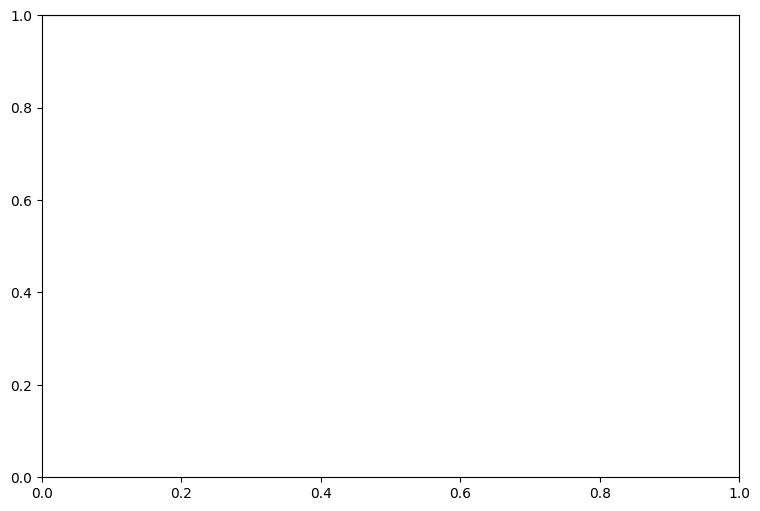

In [25]:
plt.figure(figsize=(9, 6))
plt.axhline(1, color = 'black', label = '100% Reweighted')

plt.plot(np.array(beta0_radii), hp_beta0_neg_percent, color = 'lime', marker = '*', label = 'Hard Process β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii), sho_beta0_neg_percent, color = 'mediumturquoise', marker = '*', label = 'Showered β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii), had_beta0_neg_percent, color = 'mediumpurple', marker = '*', label = 'Hadronization β = 0 EMD', linestyle = '--')

plt.xscale('log')
plt.ylim([0,1.05])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize = 12)
plt.xlabel('Cell Radius [GeV]', fontsize = 14)
plt.ylabel('Reweighted Fraction', fontsize = 14)
plt.savefig('reweight_frac.png', bbox_inches='tight')

In [ ]:
def x_at_nearest_y(radii, percent, target=0.5):
    """Return radius value whose percent is closest to target."""
    radii = np.asarray(radii, dtype=float)
    percent = np.asarray(percent, dtype=float)

    good = np.isfinite(radii) & np.isfinite(percent)
    radii = radii[good]
    percent = percent[good]

    idx = np.argmin(np.abs(percent - target))
    return radii[idx]
def plot_reweight_fractions_aligned(
    curves,
    target=0.5,
    align_to=0.0,
    normalize=False,
    figsize=(9, 6),
    save_name="reweight_frac_aligned.png",
    xlim=None
):
    """
    Plot many radius/percent curves on one figure, shifted so each curve's
    nearest point to `target` lands at x = `align_to`.

    curves should be a list of dictionaries:
        {
            "radii": radii_array,
            "percent": percent_array,
            "label": "Hard Process β = 1 EMD",
            "color": "red",
            "marker": "o",
            "linestyle": "--",
        }
    """

    fig, ax = plt.subplots(figsize=figsize)

    ax.axhline(1, color="black", label="100% Reweighted")

    for curve in curves:
        radii = np.asarray(curve["radii"], dtype=float)
        percent = np.asarray(curve["percent"], dtype=float)


        x50 = x_at_nearest_y(radii, percent, target=target)
        if normalize:
            radii = radii / x50
            x50 = x_at_nearest_y(radii, percent, target=target)
            x_plot = radii + align_to
        else:
            x_plot = radii - x50 + align_to

        ax.plot(
            x_plot,
            percent,
            color=curve.get("color", None),
            marker=curve.get("marker", "o"),
            linestyle=curve.get("linestyle", "--"),
            label=curve.get("label", None),
        )

    ax.set_ylim([0, 1.05])
    if xlim!=None:
        print(xlim[0])
        ax.set_xlim(xlim[0], xlim[1])
    ax.set_xscale("log")
    ax.set_xlabel(rf"Radius [GeV]", fontsize=14)
    ax.set_ylabel("Reweighted Fraction", fontsize=14)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=12)

    fig.savefig(save_name, bbox_inches="tight")
    return fig, ax

In [ ]:
curves = [
    # {"radii": betainf_radii, "percent": hp_betainf_neg_percent,  "color": "purple", "marker": "x", "label": "Hard Process β = ∞ EMD"},
    # {"radii": betainf_radii, "percent": sho_betainf_neg_percent, "color": "brown",  "marker": "x", "label": "Showered β = ∞ EMD"},
    # {"radii": betainf_radii, "percent": had_betainf_neg_percent, "color": "pink",   "marker": "x", "label": "Hadronization β = ∞ EMD"},

    {"radii": hp_beta2_radii,  "percent": hp_beta2_neg_percent,  "color": "mediumslateblue", "marker": "+", "label": "Hard Process β = 2 EMD"},
    {"radii": sho_beta2_radii, "percent": sho_beta2_neg_percent, "color": "plum",            "marker": "+", "label": "Showered β = 2 EMD"},
    {"radii": had_beta2_radii, "percent": had_beta2_neg_percent, "color": "midnightblue",    "marker": "+", "label": "Hadronization β = 2 EMD"},

    {"radii": hp_radii,  "percent": hp_neg_percent,  "color": "red",    "marker": "o", "label": "Hard Process β = 1 EMD"},
    {"radii": sho_radii, "percent": sho_neg_percent, "color": "blue",   "marker": "o", "label": "Showered β = 1 EMD"},
    {"radii": had_radii, "percent": had_neg_percent, "color": "orange", "marker": "o", "label": "Hadronization β = 1 EMD"},

    # {"radii": hp_beta0p5_radii,  "percent": hp_beta0p5_neg_percent,  "color": "green",       "marker": "s", "label": "Hard Process β = 0.5 EMD"},
    # {"radii": sho_beta0p5_radii, "percent": sho_beta0p5_neg_percent, "color": "magenta",     "marker": "s", "label": "Showered β = 0.5 EMD"},
    # {"radii": had_beta0p5_radii, "percent": had_beta0p5_neg_percent, "color": "lightsalmon", "marker": "s", "label": "Hadronization β = 0.5 EMD"},

    # {"radii": hp_semd_radii, "percent": hp_semd_neg_percent, "color": "cyan", "marker": "v", "label": "Hard Process p = 2 SEMD"},

    {"radii": beta0_radii, "percent": hp_beta0_neg_percent,  "color": "lime",            "marker": "*", "label": "Hard Process β = 0 EMD"},
    {"radii": beta0_radii, "percent": sho_beta0_neg_percent, "color": "mediumturquoise", "marker": "*", "label": "Showered β = 0 EMD"},
    {"radii": beta0_radii, "percent": had_beta0_neg_percent, "color": "mediumpurple",    "marker": "*", "label": "Hadronization β = 0 EMD"},

    # {"radii": hp_p1semd_radii,  "percent": hp_p1semd_neg_percent,  "color": "burlywood", "marker": "d", "label": "Hard Process p = 1 SEMD"},
    # {"radii": sho_p1semd_radii, "percent": sho_p1semd_neg_percent, "color": "olive",     "marker": "d", "label": "Showered p = 1 SEMD"},
    # {"radii": had_p1semd_radii, "percent": had_p1semd_neg_percent, "color": "turquoise", "marker": "d", "label": "Hadronization p = 1 SEMD"},
   {"radii":np.array(zjet_jeppe_df["radius"].values), "percent":zjet_jeppe_df["fraction"].values, "color":'maroon', "marker":'v', "label":'Anderson et al'}
]

In [ ]:
fig, ax = plot_reweight_fractions_aligned(
    curves,
    target=0.5,
    align_to=0.0,
    normalize=True,
    save_name="reweight_frac_aligned_50percent.png",
    xlim=[0.4, 4]
)

In [ ]:
plt.figure(figsize=(9, 6))
plt.axhline(1, color = 'black', label = '100% Reweighted')
plt.plot(np.array(betainf_radii)*(1/np.mean(betainf_radii)), hp_betainf_neg_percent, color = 'purple', marker = 'x', label = 'Hard Process β = ∞ EMD', linestyle = '--')
plt.plot(np.array(betainf_radii)*(1/np.mean(betainf_radii)), sho_betainf_neg_percent, color = 'brown', marker = 'x', label = 'Showered β = ∞ EMD', linestyle = '--')
plt.plot(np.array(betainf_radii)*(1/np.mean(betainf_radii)), had_betainf_neg_percent, color = 'pink', marker = 'x', label = 'Hadronization β = ∞ EMD', linestyle = '--')

plt.plot(np.array(hp_beta2_radii)*(1/np.mean(hp_beta2_radii))+10, hp_beta2_neg_percent, color = 'mediumslateblue', marker = '+', label = 'Hard Process β = 2 EMD', linestyle = '--')
plt.plot(np.array(sho_beta2_radii)*(1/np.mean(sho_beta2_radii))+10, sho_beta2_neg_percent, color = 'plum', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')
plt.plot(np.array(had_beta2_radii)*(1/np.mean(had_beta2_radii))+10, had_beta2_neg_percent, color = 'midnightblue', marker = '+', label = 'Showered β = 2 EMD', linestyle = '--')

plt.plot(np.array(hp_radii)*(1./np.mean(hp_radii))+20, hp_neg_percent, color = 'red', marker = 'o', label = 'Hard Process β = 1 EMD', linestyle = '--')
plt.plot(np.array(sho_radii)*(1/np.mean(sho_radii))+20, sho_neg_percent, color = 'blue', marker = 'o', label = 'Showered β = 1 EMD', linestyle = '--')
plt.plot(np.array(had_radii)*(1/np.mean(had_radii))+20, had_neg_percent, color = 'orange', marker = 'o', label = 'Hadronization β = 1 EMD', linestyle = '--')

plt.plot((np.array(hp_beta0p5_radii)*(1/np.mean(hp_beta0p5_radii)))+30, hp_beta0p5_neg_percent, color = 'green', marker = 's', label = 'Hard Process β = 0.5 EMD', linestyle = '--')
plt.plot((np.array(sho_beta0p5_radii)*(1/np.mean(sho_beta0p5_radii)))+30, sho_beta0p5_neg_percent, color = 'magenta', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')
plt.plot((np.array(had_beta0p5_radii)*(1/np.mean(had_beta0p5_radii)))+30, had_beta0p5_neg_percent, color = 'lightsalmon', marker = 's', label = 'Showered β = 0.5 EMD', linestyle = '--')

plt.plot((np.array(hp_semd_radii)*(1/np.mean(hp_semd_radii)))*40, hp_semd_neg_percent, color = 'cyan', marker = 'v', label = 'Hard Process p = 2 SEMD', linestyle = '--')

plt.plot(np.array(beta0_radii)*(1/np.mean(beta0_radii))+50, hp_beta0_neg_percent, color = 'lime', marker = '*', label = 'Hard Process β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii)*(1/np.mean(beta0_radii))+50, sho_beta0_neg_percent, color = 'mediumturquoise', marker = '*', label = 'Showered β = 0 EMD', linestyle = '--')
plt.plot(np.array(beta0_radii)*(1/np.mean(beta0_radii))+50, had_beta0_neg_percent, color = 'mediumpurple', marker = '*', label = 'Hadronization β = 0 EMD', linestyle = '--')


plt.plot(np.array(hp_p1semd_radii)*(1/np.mean(hp_p1semd_radii))+60, hp_p1semd_neg_percent, color = 'burlywood', marker = 'd', label = 'Hard Process p = 1 SEMD', linestyle = '--')
plt.plot(np.array(sho_p1semd_radii)*(1/np.mean(hp_p1semd_radii))+60, sho_p1semd_neg_percent, color = 'olive', marker = 'd', label = 'Showered p = 1 SEMD', linestyle = '--')
plt.plot(np.array(had_p1semd_radii)*(1/np.mean(hp_p1semd_radii))+60, had_p1semd_neg_percent, color = 'turquoise', marker = 'd', label = 'Hadronization p = 1 SEMD', linestyle = '--')


print(np.array(hp_semd_radii)*(70/np.max(hp_semd_radii)))
# plt.xscale('log')
plt.ylim([0,1.05])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize = 12)
plt.xlabel('Cell Radius [GeV]', fontsize = 14)
plt.ylabel('Reweighted Fraction', fontsize = 14)
plt.savefig('reweight_frac.png', bbox_inches='tight')

In [ ]:
plt.figure(figsize=(9, 6))
plt.axhline(1, color = 'black', label = '100% Reweighted')
plt.plot(np.array(betainf_radii), hp_betainf_neg_percent, color = 'purple', marker = 'x', label = 'Hard Process β = ∞ ', linestyle = '--')
plt.plot(np.array(betainf_radii), sho_betainf_neg_percent, color = 'brown', marker = 'x', label = 'Showered β = ∞', linestyle = '--')
plt.plot(np.array(betainf_radii), had_betainf_neg_percent, color = 'pink', marker = 'x', label = 'Hadronization β = ∞', linestyle = '--')

plt.plot(np.array(hp_beta2_radii), hp_beta2_neg_percent, color = 'mediumslateblue', marker = '+', label = 'Hard Process β = 2', linestyle = '--')
plt.plot(np.array(sho_beta2_radii), sho_beta2_neg_percent, color = 'plum', marker = '+', label = 'Showered β = 2', linestyle = '--')
plt.plot(np.array(had_beta2_radii), had_beta2_neg_percent, color = 'midnightblue', marker = '+', label = 'Showered β = 2', linestyle = '--')

plt.plot(np.array(hp_radii), hp_neg_percent, color = 'red', marker = 'o', label = 'Hard Process β = 1', linestyle = '--')
plt.plot(np.array(sho_radii), sho_neg_percent, color = 'blue', marker = 'o', label = 'Showered β = 1', linestyle = '--')
plt.plot(np.array(had_radii), had_neg_percent, color = 'orange', marker = 'o', label = 'Hadronization β = 1', linestyle = '--')

plt.plot(np.array(hp_beta0p5_radii), hp_beta0p5_neg_percent, color = 'green', marker = 's', label = 'Hard Process β = 0.5', linestyle = '--')
plt.plot(np.array(sho_beta0p5_radii), sho_beta0p5_neg_percent, color = 'magenta', marker = 's', label = 'Showered β = 0.5', linestyle = '--')
plt.plot(np.array(had_beta0p5_radii), had_beta0p5_neg_percent, color = 'lightsalmon', marker = 's', label = 'Showered β = 0.5', linestyle = '--')

plt.plot(np.array(hp_semd_radii), hp_semd_neg_percent, color = 'cyan', marker = 'v', label = 'Hard Process p = 2 SEMD', linestyle = '--')

plt.plot(np.array(beta0_radii), hp_beta0_neg_percent, color = 'lime', marker = '*', label = 'Hard Process β = 0', linestyle = '--')
plt.plot(np.array(beta0_radii), sho_beta0_neg_percent, color = 'mediumturquoise', marker = '*', label = 'Showered β = 0', linestyle = '--')
plt.plot(np.array(beta0_radii), had_beta0_neg_percent, color = 'mediumpurple', marker = '*', label = 'Hadronization β = 0', linestyle = '--')


plt.plot(np.array(hp_p1semd_radii), hp_p1semd_neg_percent, color = 'burlywood', marker = 'd', label = 'Hard Process p = 1 SEMD', linestyle = '--')
plt.plot(np.array(sho_p1semd_radii), sho_p1semd_neg_percent, color = 'olive', marker = 'd', label = 'Showered p = 1 SEMD', linestyle = '--')
plt.plot(np.array(had_p1semd_radii), had_p1semd_neg_percent, color = 'turquoise', marker = 'd', label = 'Hadronization p = 1 SEMD', linestyle = '--')


print(np.array(hp_semd_radii)*(70/np.max(hp_semd_radii)))
# plt.xscale('log')
plt.ylim([0,1.05])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize = 12)
plt.xlabel('Cell Radius [GeV]', fontsize = 14)
plt.ylabel('Reweighted Fraction', fontsize = 14)
plt.savefig('reweight_frac.png', bbox_inches='tight')